In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import re
import matplotlib.ticker as ticker
import math
from sklearn import decomposition
import random 

from skbio.stats.distance import DistanceMatrix
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import permanova
from statsmodels.stats.multitest import multipletests
from scipy import stats
## script from emily wissel & malena voss for kuster lab

# PEVIDS

## Urine Analysis

### Descriptive Statistics

Let's first describe how many proteins their are on average per sample.

In [2]:
## read in data
#dat_log2.to_csv("../data/urine_log2_protein_intensities.csv")
dat = pd.read_csv("../Scrips_Bachelor_Thesis/Data/urine_log2_protein_intensities_median_centered_20260618.csv")
dat.set_index("Protein.Group", inplace = True)
dat.duplicated().value_counts() # 5 dups
dat = dat.drop_duplicates()
#dat.head()
#dat.T # 1154 samples, 3239 protein groups

In [3]:
dat.duplicated().value_counts()

False    3234
Name: count, dtype: int64

In [4]:
dat.shape

(3234, 1154)

In [5]:
## subset dat by timepoint
t1_prot = dat.loc[:,dat.columns.str.endswith("_1")]
t2_prot = dat.loc[:,dat.columns.str.endswith("_2")]
t3_prot = dat.loc[:,dat.columns.str.endswith("_3")]

t1_samps = t1_prot.shape[-1]
t2_samps = t2_prot.shape[-1]
t3_samps = t3_prot.shape[-1]
print(f"There are a total of {t1_samps} urine samples at T1, {t2_samps} urine sames at T2, and {t3_samps} urine samples at T3.")

There are a total of 645 urine samples at T1, 292 urine sames at T2, and 217 urine samples at T3.


In [6]:
t1_prot = t1_prot.loc[~t1_prot.duplicated()]
t2_prot = t2_prot.loc[~t2_prot.duplicated()]
t3_prot = t3_prot.loc[~t3_prot.duplicated()]

In [7]:
t3_prot.shape

(3042, 217)

In [8]:
median_proteins_per_sample = dat.count().median()
mean_proteins_per_sample = round(dat.count().mean(), 0)
#sd_proteins_per_samp =
max_proteins_per_samp = dat.count().max()
min_proteins_per_samp = dat.count().min()

num_unique_protein_groups = len(dat.index.unique())
num_unique_samps = len(dat.columns)

In [9]:
print(f"\tOver the entire collection of data, there was a median number of {median_proteins_per_sample} proteins per urine sample, with a mean of {mean_proteins_per_sample}. There was a maximum of {max_proteins_per_samp} and minimum of {min_proteins_per_samp} proteins per sample. In total, there were {num_unique_protein_groups} unique protein groups identified in this dataset from {num_unique_samps} samples.")
print("\nLet's subswet this by the VICTORIA cohort exclusively.")

	Over the entire collection of data, there was a median number of 1193.0 proteins per urine sample, with a mean of 1192.0. There was a maximum of 1953 and minimum of 94 proteins per sample. In total, there were 3234 unique protein groups identified in this dataset from 1154 samples.

Let's subswet this by the VICTORIA cohort exclusively.


In [10]:
## subset VICTORIA only 
meta_dat = pd.read_excel("../Scrips_Bachelor_Thesis/Data/curated_metadata_pevids.xlsx")
victoria_ids = meta_dat[meta_dat['data_source'] == "victoria"]
victoria_ids = victoria_ids.drop_duplicates()

#meta_dat.head()
victoria_ids['Messzeitpunkt'].value_counts()
#victoria_ids.head()

Messzeitpunkt
1.0    325
3.0    200
2.0     91
Name: count, dtype: int64

In [11]:
## add info for treatment / control 
treat_id = pd.read_excel("../Scrips_Bachelor_Thesis/Data/entblindungsliste_20250923.xlsx", engine="openpyxl")
victoria_ids = pd.merge(victoria_ids, treat_id, on = "R_ID", how = "left")

#treat_id.head()

/usr/local/lib/python3.10/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [12]:
## other meta data 
clinic_dat = pd.read_excel("~/PEVIDS/PEVIDS_plasma/dat/meta-data/vic_data_for_moritz_final.xlsx")
clinic_dat = clinic_dat.rename(columns={"ID": "TN_ID"})
## combine
merged_meta = pd.merge(meta_dat, clinic_dat, on = "TN_ID")
merged_meta['TN_ID'] = merged_meta['TN_ID'].astype(int)
merged_meta['Messzeitpunkt'] = merged_meta['Messzeitpunkt'].astype(int)
#merged_meta.head()

In [13]:
merged_meta = pd.merge(merged_meta, treat_id, on = "R_ID")
#merged_meta.columns

In [14]:
minimet = merged_meta[["Messzeitpunkt", "TN_ID","age", "sex", "Alllocation","stage", "vit_d"]]
minimet = minimet.dropna()
minimet['TN_ID'] = minimet['TN_ID'].astype(int)
minimet['Messzeitpunkt'] = minimet['Messzeitpunkt'].astype(int)
minimet = minimet.drop_duplicates()

In [15]:
#minimet

In [16]:
victoria_ids = victoria_ids['TN_ID'].astype(int).to_list()

In [17]:
minimet = minimet[minimet['TN_ID'].isin(victoria_ids)]
minimet['Messzeitpunkt'].value_counts()

Messzeitpunkt
1    297
3    181
2     75
Name: count, dtype: int64

In [18]:
gio_tn_ids = dat.columns.to_list()
gio_tn_ids = [x.split("_")[-2] for x in gio_tn_ids]
## filter list by ids containing periods 
res = [x for x in gio_tn_ids if any(y in x for y in ".")]
print("Length of id list with periods: ",len(res))
res.sort()
resdf = pd.DataFrame(res)
    
resdf.to_csv("../results/tn_ids_with_punt.csv")

Length of id list with periods:  0


In [19]:
#res.sort()
res.sort()
resdf

""


In [20]:
minimet.mean(numeric_only=True)

Messzeitpunkt       1.790235
TN_ID            2812.757685
age                61.779385
sex                 1.663653
stage               2.209765
vit_d              31.471049
dtype: float64

In [21]:
display(minimet['stage'].value_counts())

stage
1.0    176
2.0    160
3.0    160
4.0     39
5.0     18
Name: count, dtype: int64

# PCA - timepoints

In [22]:
dat.head()
minimet.head()
minimet['TN_TP'] = minimet['TN_ID'].astype(str) + "_" + minimet['Messzeitpunkt'].astype(str)
t3_met = minimet.loc[minimet['Messzeitpunkt']==3]
t1_met = minimet.loc[minimet['Messzeitpunkt']==1]
t2_met = minimet.loc[minimet['Messzeitpunkt']==2]
#t3_met.head()

In [23]:
df_t = t1_prot.transpose()
df_t['name_from_intensity'] = df_t.index ## samples as rows
df_t['plate_num'] = df_t.apply(lambda x: '.'.join(x['name_from_intensity'].split("_")[:-2]), axis=1)
df_t['plate_num'] = np.where(df_t['plate_num'] == 'bridge', '1.1', df_t['plate_num'])
df_t['TN_ID'] = df_t.apply(lambda x:  x['name_from_intensity'].split("_")[-2], axis = 1)
df_t['TP'] = df_t.apply(lambda x:  x['name_from_intensity'].split("_")[-1], axis = 1)
df_t['TN_ID'] = df_t['TN_ID'].astype(int)
## unique ID
df_t['TN_TP'] =  df_t['TN_ID'].astype(str) + "_" + df_t['TP'].astype(str)
print("before merge: ", df_t.shape[0])
df_t = pd.merge(df_t, t1_met, on = ["TN_TP", "TN_ID"], how = "inner")
df_t_2 = pd.DataFrame(df_t) ## for backwards compatibility 
df_t_2 = df_t_2.dropna(subset=["TN_ID", "Messzeitpunkt"])
print("after merge: ", df_t_2.shape[0])
df_t_2.index = df_t_2['name_from_intensity']
print("unique tn ids according to ms data: ", len(df_t_2['TN_ID'].unique()))
df_t_2 = df_t_2.drop(['name_from_intensity', "TN_TP","Alllocation", 'plate_num', "Messzeitpunkt", "TN_ID"], axis = 1)
df_no_nas = df_t_2.fillna(0, inplace = False)
## remove protein groups with all zeroes 
df_no_nas.drop(columns=df_no_nas.columns[df_no_nas.sum()==0], inplace=True)

before merge:  645
after merge:  291
unique tn ids according to ms data:  291


In [24]:
pca = decomposition.PCA(n_components=2)
pca.fit(df_no_nas)
pc = pca.transform(df_no_nas)
pc_df = pd.DataFrame(
        data=pc,
        columns = ['pc1', 'pc2'],
        index=df_t['plate_num']    
    )

In [25]:
df_name = str("Baseline PCA, Urine")
## get palette
print("there are a total of ", len(df_t['plate_num'].unique()), " unique plates.")
palette_len = len(df_t['plate_num'].unique())
custom_palette = sns.color_palette("tab20b", palette_len)

there are a total of  13  unique plates.


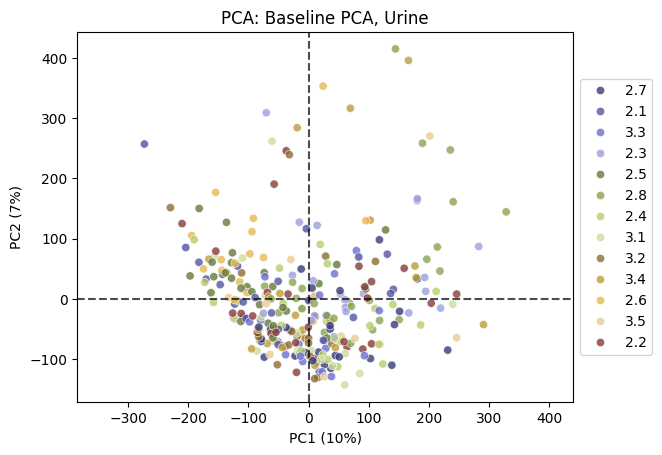

In [26]:
ax = sns.scatterplot(data=pc_df, x=pc_df["pc1"], y=pc_df["pc2"], hue = pc_df.index, alpha = 0.8, palette = custom_palette)
plt.axhline(y=0, color = "black", ls = "--", alpha = 0.7) 
plt.axvline(x=0, color = "black", ls = "--", alpha = 0.7) 
#pc_df.apply(lambda x: ax.text(x['PC1']+0.05, x['PC2'], x.name), axis=1);
plt.xlabel(f'PC1 ({int(pca.explained_variance_ratio_[0]*100)}%)')
plt.ylabel(f'PC2 ({int(pca.explained_variance_ratio_[1]*100)}%)')
ax.set(title = f"PCA: {df_name}")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)
plt.axis('equal')
#ax.figure.savefig(f"../results/02_qc_pca_{df_name}.png", dpi = 300,  bbox_inches='tight') 

plt.show()

combined samples across T1+T2+T3:  540
Messzeitpunkt
1    291
3    173
2     76
Name: count, dtype: int64


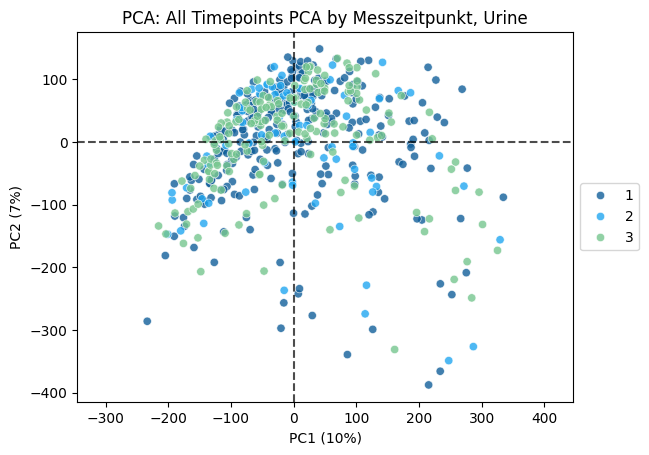

In [27]:
## helper to build one timepoint's sample-level dataframe (protein data + metadata)
def prep_timepoint(prot_df, met_df):
    d = prot_df.transpose()
    d['name_from_intensity'] = d.index
    d['plate_num'] = d.apply(lambda x: '.'.join(x['name_from_intensity'].split("_")[:-2]), axis=1)
    d['plate_num'] = np.where(d['plate_num'] == 'bridge', '1.1', d['plate_num'])
    d['TN_ID'] = d.apply(lambda x: x['name_from_intensity'].split("_")[-2], axis=1)
    d['TP'] = d.apply(lambda x: x['name_from_intensity'].split("_")[-1], axis=1)
    d['TN_ID'] = d['TN_ID'].astype(int)
    d['TN_TP'] = d['TN_ID'].astype(str) + "_" + d['TP'].astype(str)
    d = pd.merge(d, met_df, on=["TN_TP", "TN_ID"], how="inner")
    return d

## build and combine all three timepoints
df_t1 = prep_timepoint(t1_prot, t1_met)
df_t2 = prep_timepoint(t2_prot, t2_met)
df_t3 = prep_timepoint(t3_prot, t3_met)

df_t = pd.concat([df_t1, df_t2, df_t3], axis=0, ignore_index=True)
df_t = df_t.dropna(subset=["TN_ID", "Messzeitpunkt"])
df_t.index = df_t['name_from_intensity']
print("combined samples across T1+T2+T3: ", df_t.shape[0])
print(df_t['Messzeitpunkt'].value_counts())

df_t_2 = df_t.drop(['name_from_intensity', "TN_TP", "Alllocation", 'plate_num', "Messzeitpunkt", "TN_ID"], axis=1)
df_no_nas = df_t_2.fillna(0, inplace=False)
## remove protein groups with all zeroes
df_no_nas.drop(columns=df_no_nas.columns[df_no_nas.sum()==0], inplace=True)

### PCA by Messzeitpunkt, all timepoints combined
df_name = str("All Timepoints PCA by Messzeitpunkt, Urine")
pca = decomposition.PCA(n_components=2)
pca.fit(df_no_nas)
pc = pca.transform(df_no_nas)
pc_df = pd.DataFrame(
    data=pc,
    columns=['pc1', 'pc2'],
    index=df_t['Messzeitpunkt']
)

custom_palette = {
    1.0: '#115f9a',
    2.0: '#22a7f0',
    3.0: '#76c68f',
}

ax = sns.scatterplot(data=pc_df, x=pc_df["pc1"], y=pc_df["pc2"], hue=pc_df.index, alpha=0.8, palette=custom_palette)
plt.axhline(y=0, color="black", ls="--", alpha=0.7)
plt.axvline(x=0, color="black", ls="--", alpha=0.7)
plt.xlabel(f'PC1 ({int(pca.explained_variance_ratio_[0]*100)}%)')
plt.ylabel(f'PC2 ({int(pca.explained_variance_ratio_[1]*100)}%)')
ax.set(title=f"PCA: {df_name}")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)
plt.axis('equal')
ax.figure.savefig(f"../results/02_qc_pca_{df_name}.png", dpi=300, bbox_inches='tight')
plt.show()

In [28]:
## last timepoint 
df_name = str("T3 PCA, Urine")
df_t = t3_prot.transpose()
df_t['name_from_intensity'] = df_t.index ## samples as rows
df_t['plate_num'] = df_t.apply(lambda x: '.'.join(x['name_from_intensity'].split("_")[:-2]), axis=1)
df_t['plate_num'] = np.where(df_t['plate_num'] == 'bridge', '1.1', df_t['plate_num'])
df_t['TN_ID'] = df_t.apply(lambda x:  x['name_from_intensity'].split("_")[-2], axis = 1)
df_t['TP'] = df_t.apply(lambda x:  x['name_from_intensity'].split("_")[-1], axis = 1)
df_t['TN_ID'] = df_t['TN_ID'].astype(int)
## unique ID
df_t['TN_TP'] =  df_t['TN_ID'].astype(str) + "_" + df_t['TP'].astype(str)
print("before merge: ", df_t.shape[0])
df_t = pd.merge(df_t, t3_met, on = ["TN_TP", "TN_ID"], how = "inner")
df_t_2 = pd.DataFrame(df_t) ## for backwards compatibility 
df_t_2 = df_t_2.dropna(subset=["TN_ID", "Messzeitpunkt"])
print("after merge: ", df_t_2.shape[0])
df_t_2.index = df_t_2['name_from_intensity']
print("unique tn ids according to ms data: ", len(df_t_2['TN_ID'].unique()))
df_t_2 = df_t_2.drop(['name_from_intensity', "TN_TP","Alllocation", 'plate_num', "Messzeitpunkt", "TN_ID"], axis = 1)
df_no_nas = df_t_2.fillna(0, inplace = False)
## remove protein groups with all zeroes 
df_no_nas.drop(columns=df_no_nas.columns[df_no_nas.sum()==0], inplace=True)

before merge:  217
after merge:  173
unique tn ids according to ms data:  173


there are a total of  13  unique plates.


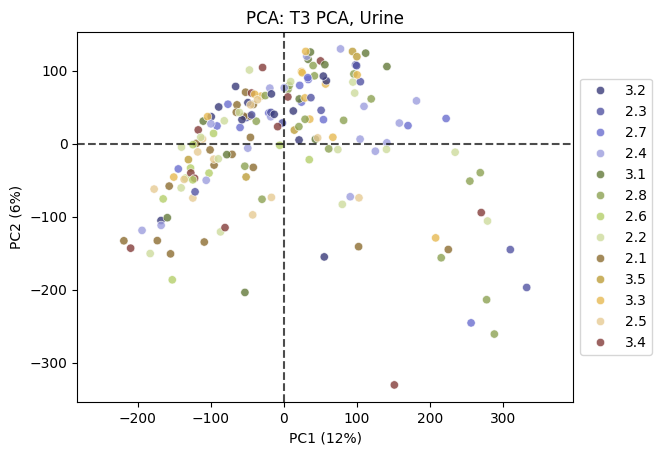

In [29]:
pca = decomposition.PCA(n_components=2)
pca.fit(df_no_nas)
pc = pca.transform(df_no_nas)
pc_df = pd.DataFrame(
        data=pc,
        columns = ['pc1', 'pc2'],
        index=df_t['plate_num']    
    )
    ## get palette
print("there are a total of ", len(df_t['plate_num'].unique()), " unique plates.")
palette_len = len(df_t['plate_num'].unique())
############
custom_palette = sns.color_palette("tab20b", palette_len)
ax = sns.scatterplot(data=pc_df, x=pc_df["pc1"], y=pc_df["pc2"], hue = pc_df.index, alpha = 0.8, palette = custom_palette)
plt.axhline(y=0, color = "black", ls = "--"
            , alpha = 0.7) 
plt.axvline(x=0, color = "black", ls = "--", alpha = 0.7) 
#pc_df.apply(lambda x: ax.text(x['PC1']+0.05, x['PC2'], x.name), axis=1);
plt.xlabel(f'PC1 ({int(pca.explained_variance_ratio_[0]*100)}%)')
plt.ylabel(f'PC2 ({int(pca.explained_variance_ratio_[1]*100)}%)')
ax.set(title = f"PCA: {df_name}")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)
plt.axis('equal')
#ax.figure.savefig(f"../results/02_qc_pca_{df_name}.png", dpi = 300,  bbox_inches='tight') 

plt.show()

In [30]:
#df_t.head()

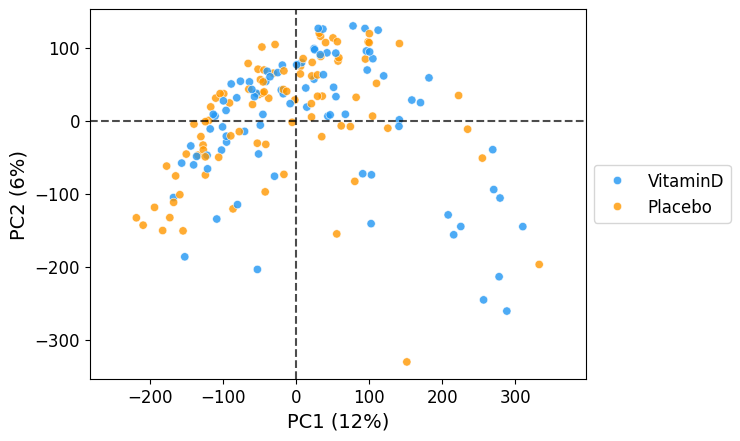

In [31]:
### another
df_name = str("T3 PCA by Allocation, Urine")
pca = decomposition.PCA(n_components=2)
pca.fit(df_no_nas)
pc = pca.transform(df_no_nas)
pc_df = pd.DataFrame(
    data=pc,
    columns=['pc1', 'pc2'],
    index=df_t['Alllocation']
)
## palette — explicit mapping by allocation label
custom_palette = {
    'VitaminD': '#2196F3',
    'Placebo':  '#FF9800',
}
ax = sns.scatterplot(data=pc_df, x=pc_df["pc1"], y=pc_df["pc2"], hue=pc_df.index, alpha=0.8, palette=custom_palette)
plt.axhline(y=0, color="black", ls="--", alpha=0.7)
plt.axvline(x=0, color="black", ls="--", alpha=0.7)
plt.xlabel(f'PC1 ({int(pca.explained_variance_ratio_[0]*100)}%)', fontsize=14)
plt.ylabel(f'PC2 ({int(pca.explained_variance_ratio_[1]*100)}%)', fontsize=14)
#ax.set_title(f"PCA: {df_name}", fontsize=16)
ax.tick_params(axis='both', labelsize=12)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1, fontsize=12, title_fontsize=13)
plt.axis('equal')
ax.figure.savefig(f"../results/02_qc_pca_{df_name}.png", dpi=300, bbox_inches='tight')
plt.show()

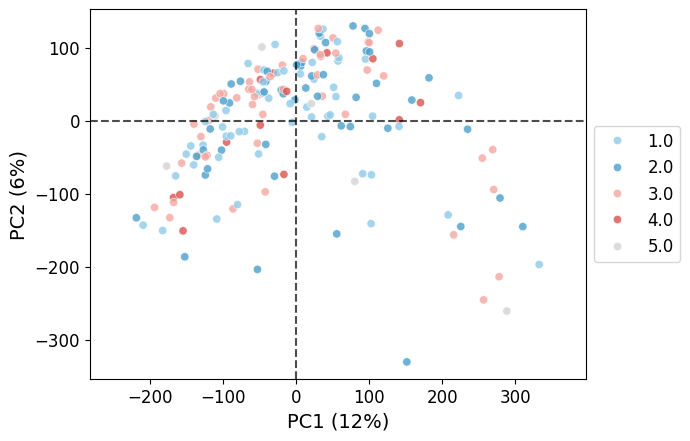

In [32]:
### another
df_name = str("T3 PCA by CRC Stage (5 is unknown), Urine")
pca = decomposition.PCA(n_components=2)
pca.fit(df_no_nas)
pc = pca.transform(df_no_nas)
pc_df = pd.DataFrame(
        data=pc,
        columns=['pc1', 'pc2'],
        index=df_t['stage']    
    )
## custom palette keyed by stage
custom_palette = {
    1.0: '#8FCBE8',  # early - light blue
    2.0: '#4A9FCB',  # early - darker blue
    3.0: '#F4A6A0',  # late - light coral
    4.0: '#D9534F',  # late - darker coral/red
    5.0: '#D4D4D4',  # unknown - neutral grey
}
ax = sns.scatterplot(data=pc_df, x=pc_df["pc1"], y=pc_df["pc2"], hue=pc_df.index, alpha=0.8, palette=custom_palette)
plt.axhline(y=0, color="black", ls="--", alpha=0.7)
plt.axvline(x=0, color="black", ls="--", alpha=0.7)
plt.xlabel(f'PC1 ({int(pca.explained_variance_ratio_[0]*100)}%)', fontsize=14)
plt.ylabel(f'PC2 ({int(pca.explained_variance_ratio_[1]*100)}%)', fontsize=14)
#ax.set_title(f"PCA: {df_name}", fontsize=16)
ax.tick_params(axis='both', labelsize=12)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1, fontsize=12, title_fontsize=13)
plt.axis('equal')
ax.figure.savefig(f"../results/02_qc_pca_{df_name}.png", dpi=300, bbox_inches='tight')
plt.show()

In [33]:
t3_prot.duplicated().value_counts()

False    3042
Name: count, dtype: int64

## Permanova 
### Treatment Only 

In [34]:
minimet[['Messzeitpunkt','Alllocation']].value_counts()

Messzeitpunkt  Alllocation
1              Placebo        150
               VitaminD       147
3              Placebo         96
               VitaminD        85
2              VitaminD        40
               Placebo         35
Name: count, dtype: int64

In [35]:
## last timepoint 
df_t = t3_prot.transpose()
df_t['name_from_intensity'] = df_t.index ## samples as rows
df_t['plate_num'] = df_t.apply(lambda x: '.'.join(x['name_from_intensity'].split("_")[:-2]), axis=1)
df_t['plate_num'] = np.where(df_t['plate_num'] == 'bridge', '1.1', df_t['plate_num'])
df_t['TN_ID'] = df_t.apply(lambda x:  x['name_from_intensity'].split("_")[-2], axis = 1)
df_t['TP'] = df_t.apply(lambda x:  x['name_from_intensity'].split("_")[-1], axis = 1)
df_t['TN_ID'] = df_t['TN_ID'].astype(int)
## unique ID
df_t['TN_TP'] =  df_t['TN_ID'].astype(str) + "_" + df_t['TP'].astype(str)
print("before merge: ", df_t.shape[0])
df_t = pd.merge(df_t, minimet, on = ["TN_TP", "TN_ID"], how = "inner")
df_t_2 = pd.DataFrame(df_t) ## for backwards compatibility 
df_t_2 = df_t_2.dropna(subset=["TN_ID", "Messzeitpunkt"])
print("after merge: ", df_t_2.shape[0])
df_t_2.index = df_t_2['name_from_intensity']
df_t_2 = df_t_2.drop(['name_from_intensity', "TN_TP","Alllocation", 'plate_num', "Messzeitpunkt", "TN_ID"], axis = 1)
df_no_nas = df_t_2.fillna(0, inplace = False)
## remove protein groups with all zeroes 
t3_no_nas = df_no_nas.drop(columns=df_no_nas.columns[df_no_nas.sum()==0])
t3_no_nas = t3_no_nas.drop(['stage','TP', 'age', 'sex'], axis = 1)
#t3_no_nas.head()

before merge:  217
after merge:  173


In [36]:
prot_all = t3_no_nas.values
dist_sq_all = squareform(pdist(prot_all, metric="euclidean"))
ids_all = t3_no_nas.index.astype(str).tolist()
dm_all = DistanceMatrix(dist_sq_all, ids=ids_all)
## pull out group info
grouping_treatment = df_t["Alllocation"].copy()
grouping_treatment.index = t3_no_nas.index
result_treatment = permanova(dm_all, 
                            grouping_treatment, 
                            permutations=999, 
                            seed = 20150611)
print(result_treatment)

method name               PERMANOVA
test statistic name        pseudo-F
sample size                     173
number of groups                  2
test statistic             1.514379
p-value                       0.028
number of permutations          999
Name: PERMANOVA results, dtype: object


In [96]:
#!wget https://raw.githubusercontent.com/ivanp1994/PyPerMANOVA/main/PyPerMANOVA.py

In [38]:
!sed -i 's/from scipy.stats.stats import _unequal_var_ttest_denom/from scipy.stats._stats_py import _unequal_var_ttest_denom/' ~/Scrips_Bachelor_Thesis/PyPerMANOVA.py

In [39]:
t3_no_nas.shape # 173, 3001
#df_t.shape #173, 3050
min_t3_meta = df_t[["name_from_intensity", "plate_num","TN_ID","TP", "TN_TP", "Alllocation","stage"]]
stage_map = {1: "early", 2: "early", 3: "late", 4: "late"}
min_t3_meta["Allocation_stage"] = (
        min_t3_meta["Alllocation"] + "_" + min_t3_meta["stage"].map(stage_map)
    )
#min_t3_meta.head()

/tmp/ipykernel_86372/495486205.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_t3_meta["Allocation_stage"] = (


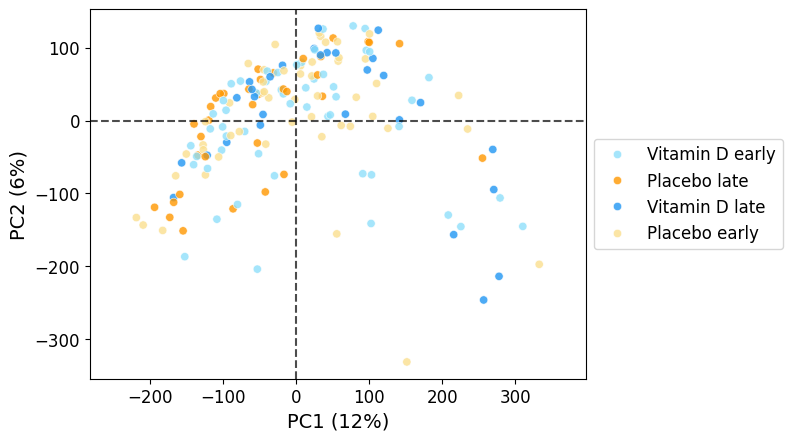

In [40]:
### PCA by Allocation_stage, T3 Urine
df_name = str("T3 PCA by Treatment and CRC Stage, Urine")
pca = decomposition.PCA(n_components=2)
pca.fit(t3_no_nas)
pc = pca.transform(t3_no_nas)
pc_df = pd.DataFrame(
    data=pc,
    columns=['pc1', 'pc2'],
    index=min_t3_meta['Allocation_stage']
)
## palette — explicit mapping by allocation + stage
custom_palette = {
    "VitaminD_early": "#8FDFFA",
    "VitaminD_late":  "#2196F3",
    "Placebo_early":  "#FADF8F",
    "Placebo_late":   "#FF9800",
}
## legend label mapping (display text only — doesn't touch the data)
legend_labels = {
    "VitaminD_early": "Vitamin D early",
    "VitaminD_late":  "Vitamin D late",
    "Placebo_early":  "Placebo early",
    "Placebo_late":   "Placebo late",
}

ax = sns.scatterplot(data=pc_df, x=pc_df["pc1"], y=pc_df["pc2"], hue=pc_df.index, alpha=0.8, palette=custom_palette)
plt.axhline(y=0, color="black", ls="--", alpha=0.7)
plt.axvline(x=0, color="black", ls="--", alpha=0.7)
plt.xlabel(f'PC1 ({int(pca.explained_variance_ratio_[0]*100)}%)', fontsize=14)
plt.ylabel(f'PC2 ({int(pca.explained_variance_ratio_[1]*100)}%)', fontsize=14)
#ax.set_title(f"PCA: {df_name}", fontsize=16)
ax.tick_params(axis='both', labelsize=12)

handles, labels = ax.get_legend_handles_labels()
labels = [legend_labels.get(l, l) for l in labels]
ax.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5), ncol=1, fontsize=12, title_fontsize=13)

plt.axis('equal')
ax.figure.savefig(f"../results/02_qc_pca_{df_name}.png", dpi=300, bbox_inches='tight')
plt.show()

In [41]:
min_t3_meta["Allocation_stage"].value_counts()

Allocation_stage
VitaminD_early    53
Placebo_early     50
Placebo_late      35
VitaminD_late     29
Name: count, dtype: int64

In [42]:
#copy PyPerMANOVA Github
from PyPerMANOVA import permutational_analysis

min_t3_meta_aligned = min_t3_meta.set_index("name_from_intensity").reindex(t3_no_nas.index)

mask = min_t3_meta_aligned["Allocation_stage"].notna()
t3_no_nas_clean = t3_no_nas.loc[mask]
mapping_clean = min_t3_meta_aligned.loc[mask, "Allocation_stage"]

permanova_result, posthoc_result = permutational_analysis(
    data=t3_no_nas_clean.T,
    mapping=mapping_clean,
    norm="row",
    metric="euclidean",
    permutations=999
)

# recalculate with FDR-BH instead of Bonferroni
_, fdr_pvals, _, _ = multipletests(posthoc_result['Pval'], method='fdr_bh')
posthoc_result['fdr'] = fdr_pvals

print(permanova_result)
print(posthoc_result[['A', 'B', 'Pval', 'bonf', 'fdr', 'eta-sqr', 'cohen-d']])

    Pval   eta-sqr         F
0  0.109  0.020521  1.138325
                A              B   Pval   bonf     fdr   eta-sqr   cohen-d
0  VitaminD_early   Placebo_late  0.099  0.594  0.2970  0.013994  0.238403
1  VitaminD_early  VitaminD_late  0.437  2.622  0.5244  0.012367  0.233901
2  VitaminD_early  Placebo_early  0.956  5.736  0.9560  0.007893  0.178423
3    Placebo_late  VitaminD_late  0.005  0.030  0.0300  0.030290  0.365639
4    Placebo_late  Placebo_early  0.248  1.488  0.3720  0.012706  0.227190
5   VitaminD_late  Placebo_early  0.199  1.194  0.3720  0.014561  0.255427


In [43]:
#min_t3_meta_aligned

In [44]:
kruskal_data = df_t.copy()
protein_cols = df_t.drop(["name_from_intensity","plate_num","TN_ID","TP","TN_TP", "Messzeitpunkt","Alllocation", "stage"], axis=1).columns.to_list()

results = []
sufficient_count = 0
for protein in protein_cols:
    group1 = kruskal_data[kruskal_data['Alllocation'] == "Placebo"][protein].dropna()
    group3 = kruskal_data[kruskal_data['Alllocation'] == "VitaminD"][protein].dropna()
    group1_obs = group1.count()
    group3_obs = group3.count()
    if group1_obs < 30 or group3_obs < 30:
        ## skip if fewer than 30 samples in EITHER group with the protein of interest
        pass
    else:
        sufficient_count += 1
        stat, p = stats.kruskal(group1, group3)
        results.append({'protein': protein, 'stat': stat, 'p_value': p})

kruskal_results = pd.DataFrame(results).sort_values('p_value')
kruskal_results = kruskal_results.dropna(subset=['p_value'])  # drop cases where kruskal returned NaN (e.g. zero-variance group)

reject, p_adj, _, _ = multipletests(kruskal_results['p_value'], method='fdr_bh')
kruskal_results['p_adj'] = p_adj
kruskal_results['significant'] = reject

print(f"Number of protein groups with sufficient observations for testing: {sufficient_count}")
print(f"Total proteins tested: {len(kruskal_results)}")
print(f"Significant after FDR correction: {kruskal_results['significant'].sum()}")
print(f"Proportion significant: {kruskal_results['significant'].mean():.1%}")
kruskal_results[kruskal_results['significant']].sort_values('p_adj')

Number of protein groups with sufficient observations for testing: 1259
Total proteins tested: 1259
Significant after FDR correction: 0
Proportion significant: 0.0%


,protein,stat,p_value,p_adj,significant


In [45]:
kruskal_data = df_t.copy()
stage_map = {1: "early", 2: "early", 3: "late", 4: "late"}
kruskal_data["Allocation_stage"] = (
    kruskal_data["Alllocation"] + "_" + kruskal_data["stage"].map(stage_map)
)
protein_cols = df_t.drop(
    ["name_from_intensity","plate_num","TN_ID","TP","TN_TP",
     "Messzeitpunkt","Alllocation","stage"], axis=1
).columns.to_list()

In [46]:
# Vitamin D late + Placebo late
kruskal_data = kruskal_data.reset_index(drop=True)
group_a = kruskal_data[kruskal_data['Allocation_stage'] == 'VitaminD_late']
group_b = kruskal_data[kruskal_data['Allocation_stage'] == 'Placebo_late']
whitney_results = []
for protein in protein_cols:
    a = group_a[protein].dropna()
    b = group_b[protein].dropna()
    if len(a) < 10 or len(b) < 10:   # match whatever MIN_N you settled on elsewhere
        continue
    stat, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    whitney_results.append({'protein': protein, 'stat': stat, 'p_value': p, 'n_a': len(a), 'n_b': len(b)})
whitney_results = pd.DataFrame(whitney_results).sort_values('p_value')
whitney_results = whitney_results.dropna(subset=['p_value'])
reject, p_adj, _, _ = multipletests(whitney_results['p_value'], method='fdr_bh')
whitney_results['p_adj'] = p_adj
whitney_results['significant'] = reject
print(f"Total proteins tested: {len(whitney_results)}")
print(f"Significant after FDR correction: {whitney_results['significant'].sum()}")
print(f"Proportion significant: {whitney_results['significant'].mean():.1%}")
whitney_results[whitney_results['significant']].sort_values('p_adj')

Total proteins tested: 1282
Significant after FDR correction: 0
Proportion significant: 0.0%


,protein,stat,p_value,n_a,n_b,p_adj,significant


In [47]:
kruskal_data['Allocation_stage'].value_counts()

Allocation_stage
VitaminD_early    53
Placebo_early     50
Placebo_late      35
VitaminD_late     29
Name: count, dtype: int64

In [48]:
kruskal_results.dropna(subset=["p_value"])

,protein,stat,p_value,p_adj,significant
55,O00468,10.779897,0.001026,0.262832,False
702,P51884,10.770764,0.001031,0.262832,False
611,P31944,9.960992,0.001599,0.262832,False
337,P07741,9.507322,0.002047,0.262832,False
304,P06576,9.363002,0.002214,0.262832,False
...,...,...,...,...,...
984,Q7Z5N4,0.000049,0.994398,0.997530,False
175,P01009,0.000037,0.995153,0.997530,False
82,O43166,0.000019,0.996551,0.998136,False
357,P08519,0.000000,1.000000,1.000000,False


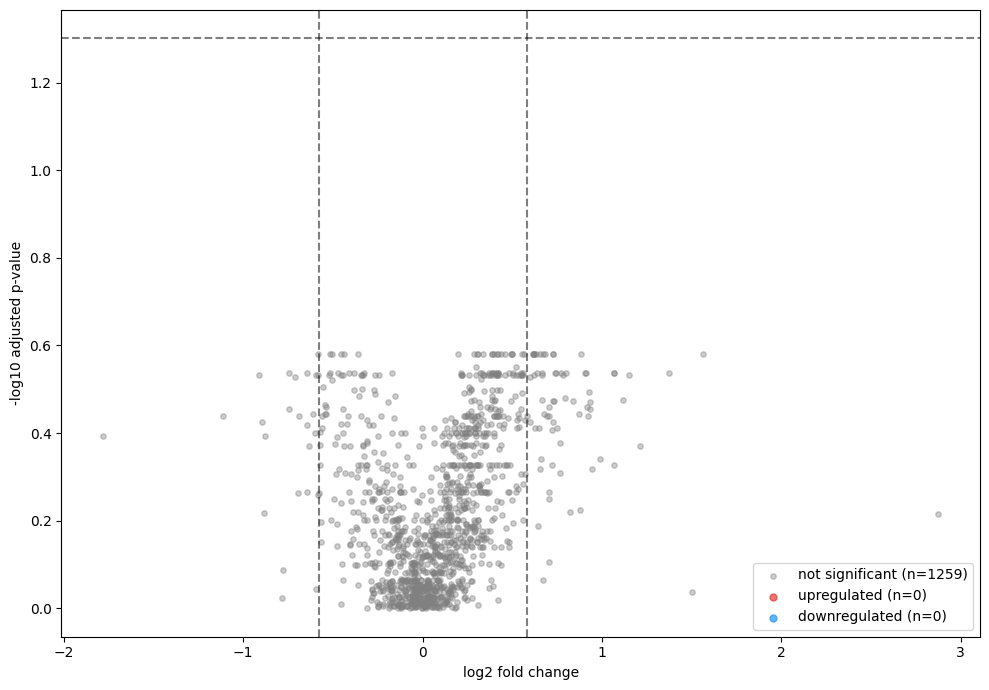

In [49]:
## follow up u test
# calculate log2 fold change  = difference in medians
fold_changes = []
for protein in kruskal_results['protein']:
    med1 = kruskal_data[kruskal_data['Alllocation'] == "Placebo"][protein].median()
    med3 = kruskal_data[kruskal_data['Alllocation'] == "VitaminD"][protein].median()
    log2fc = med3 - med1
    fold_changes.append(log2fc)

kruskal_results['log2fc'] = fold_changes
kruskal_results['log2fc'] = fold_changes
kruskal_results['-log10_p_adj'] = -np.log10(kruskal_results['p_adj'])

FC_THRESH = 0.58
PVAL_THRESH = 0.05

def classify(row):
    if not row['significant'] or abs(row['log2fc']) < FC_THRESH:
        return 'not significant'
    elif row['log2fc'] > FC_THRESH:
        return 'upregulated'
    else:
        return 'downregulated'

kruskal_results['direction'] = kruskal_results.apply(classify, axis=1)

color_map = {
    'not significant': 'grey',
    'upregulated':     '#E53935',
    'downregulated':   '#2196F3',
}

fig, ax = plt.subplots(figsize=(10, 7))
for group, color in color_map.items():
    subset = kruskal_results[kruskal_results['direction'] == group]
    ax.scatter(subset['log2fc'], subset['-log10_p_adj'],
               color=color, alpha=0.7 if group != 'not significant' else 0.4,
               s=25 if group != 'not significant' else 15,
               label=f"{group} (n={len(subset)})")

ax.axhline(y=-np.log10(PVAL_THRESH), color='black', ls='--', alpha=0.5)
ax.axvline(x= FC_THRESH, color='black', ls='--', alpha=0.5)
ax.axvline(x=-FC_THRESH, color='black', ls='--', alpha=0.5)

for _, row in kruskal_results[kruskal_results['direction'] != 'not significant'].iterrows():
    ax.annotate(row['protein'], xy=(row['log2fc'], row['-log10_p_adj']),
                fontsize=7, ha='left', va='bottom')

ax.set_xlabel('log2 fold change')
ax.set_ylabel('-log10 adjusted p-value')
#ax.set_title('Volcano plot: T3 Allocation')
ax.legend()
plt.tight_layout()
plt.savefig("../results/03_volcano_allocation_t3.png", dpi=300)
plt.show()

In [50]:
fold_changes = []
for protein in whitney_results['protein']:
    med_a = group_a[protein].median()   # VitaminD_late
    med_b = group_b[protein].median()   # Placebo_late
    log2fc = med_a - med_b
    fold_changes.append(log2fc)

whitney_results['log2fc'] = fold_changes
whitney_results['-log10_p_adj'] = -np.log10(whitney_results['p_adj'])

FC_THRESH = 0.58
PVAL_THRESH = 0.05

def classify(row):
    if not row['significant'] or abs(row['log2fc']) < FC_THRESH:
        return 'not significant'
    elif row['log2fc'] > FC_THRESH:
        return 'upregulated'
    else:
        return 'downregulated'

whitney_results['direction'] = whitney_results.apply(classify, axis=1)

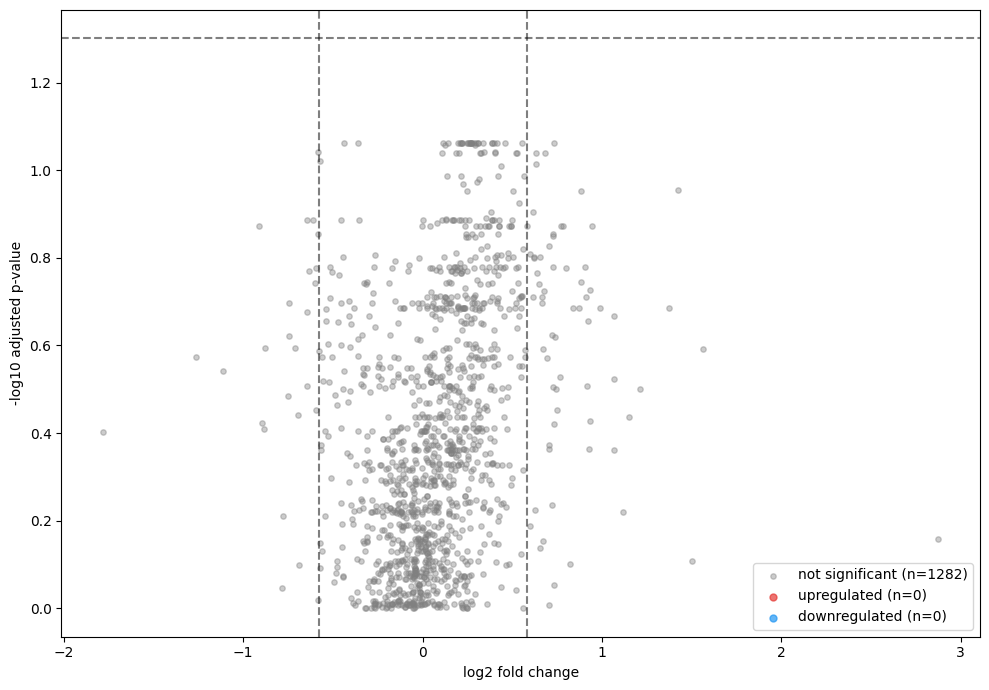

In [52]:
## follow up u test
# calculate log2 fold change  = difference in medians
fold_changes = []
for protein in whitney_results['protein']:
    med1 = kruskal_data[kruskal_data['Alllocation'] == "Placebo"][protein].median()
    med3 = kruskal_data[kruskal_data['Alllocation'] == "VitaminD"][protein].median()
    log2fc = med3 - med1
    fold_changes.append(log2fc)

whitney_results['log2fc'] = fold_changes
whitney_results['log2fc'] = fold_changes
whitney_results['-log10_p_adj'] = -np.log10(whitney_results['p_adj'])

FC_THRESH = 0.58
PVAL_THRESH = 0.05

def classify(row):
    if not row['significant'] or abs(row['log2fc']) < FC_THRESH:
        return 'not significant'
    elif row['log2fc'] > FC_THRESH:
        return 'upregulated'
    else:
        return 'downregulated'

whitney_results['direction'] = whitney_results.apply(classify, axis=1)

color_map = {
    'not significant': 'grey',
    'upregulated':     '#E53935',
    'downregulated':   '#2196F3',
}

fig, ax = plt.subplots(figsize=(10, 7))
for group, color in color_map.items():
    subset = whitney_results[whitney_results['direction'] == group]
    ax.scatter(subset['log2fc'], subset['-log10_p_adj'],
               color=color, alpha=0.7 if group != 'not significant' else 0.4,
               s=25 if group != 'not significant' else 15,
               label=f"{group} (n={len(subset)})")

ax.axhline(y=-np.log10(PVAL_THRESH), color='black', ls='--', alpha=0.5)
ax.axvline(x= FC_THRESH, color='black', ls='--', alpha=0.5)
ax.axvline(x=-FC_THRESH, color='black', ls='--', alpha=0.5)

for _, row in whitney_results[whitney_results['direction'] != 'not significant'].iterrows():
    ax.annotate(row['protein'], xy=(row['log2fc'], row['-log10_p_adj']),
                fontsize=7, ha='left', va='bottom')

ax.set_xlabel('log2 fold change')
ax.set_ylabel('-log10 adjusted p-value')
#ax.set_title('Volcano plot: T3 Allocation and Stage')
ax.legend()
plt.tight_layout()
plt.savefig("../results/03_volcano_allocation_stage_t3.png", dpi=300)
plt.show()